# Prefix search (rinna)

`prefix_search.ipynb` の rinna の日本語 GPT 版（`MODEL_NAME` で rinna/japanese-gpt2-small か rinna/japanese-gpt-1b を選ぶ）。現在 token（suffix）を固定し、語彙中のすべての過去 token（prefix）について $T^{ee}$（LN あり）と日本語 Wikipedia（20231101.ja）での bigram 数を並べる。

`bash scripts/compute_data_rinna.sh frequency`（1b なら `MODEL=rinna/japanese-gpt-1b` を付ける）で頻度（`outputs/corpus-tools/` の下）を作っておく。tokenizer は tokenizer-tools のもの（特殊トークンは付けない。gpt2-small は小文字にしてから tokenize する）。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from feature_extractor.models import load_tokenizer

from lm_detokenization.analysis.detokenization import TokenAffinity, roc
from lm_detokenization.data.corpus import counts_dir, load_bigram_counts
from lm_detokenization.tokens import token_text
from lm_detokenization.weights import load_layer0_weights

ROOT = Path.cwd().parent  # notebooks/ -> repository root
MODEL_NAME = "rinna/japanese-gpt2-small"  # or "rinna/japanese-gpt-1b"
CORPUS = "wikipedia-ja"
# Japanese tokens in the figures: the first of these fonts found
plt.rcParams["font.sans-serif"] = ["Hiragino Sans", "Noto Sans CJK JP", "IPAexGothic", "DejaVu Sans"]

tokenizer = load_tokenizer(MODEL_NAME)
affinity = TokenAffinity.from_weights(load_layer0_weights(MODEL_NAME))
bigrams = load_bigram_counts(ROOT / counts_dir(MODEL_NAME, CORPUS)).tocsc()
# token as written in the paper, with "_" for a leading space ("▁")
TOKENS = [token_text(tokenizer, i) for i in range(len(tokenizer))]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: rinna/japanese-gpt2-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


]8;id=943472;file:///Users/238-gs20253502/Documents/codes/phd/lm-detokenization/.venv/lib/python3.13/site-packages/feature_extractor/models/load.py\load.py]8;;\:]8;id=911997;file:///Users/238-gs20253502/Documents/codes/phd/lm-detokenization/.venv/lib/python3.13/site-packages/feature_extractor/models/load.py#33\33]8;;\
2026-10-06 09:25:51,743/INFO/feature_extractor.models.load/load_causal_model():33                                  
Model loaded on device: cpu                                                                                        

In [2]:
def search(word: str) -> pl.DataFrame:
    """T^ee and bigram count of every (prefix, suffix) pair for every head,
    with the last token of `word` as the suffix."""
    suffix_id = tokenizer.encode(word, add_special_tokens=False)[-1]
    print(f"suffix: {TOKENS[suffix_id]!r} ({suffix_id})")
    scores = affinity.suffix_scores([suffix_id])[0].numpy()  # [head, prefix]
    num_heads, vocab_size = scores.shape
    counts = bigrams[:, suffix_id].toarray().ravel()
    return pl.DataFrame(
        {
            "prefix_id": np.tile(np.arange(vocab_size), num_heads),
            "suffix_id": suffix_id,
            "head": np.repeat(np.arange(num_heads), vocab_size),
            "score": scores.ravel(),
            "count": np.tile(counts, num_heads),
        }
    ).with_columns(
        pl.col("prefix_id")
        .map_elements(lambda i: TOKENS[i] + TOKENS[suffix_id].lstrip("_"), return_dtype=pl.String)
        .alias("detokenization")
    )

In [13]:
df = search("カレーパン")
df

suffix: 'パン' (1077)


prefix_id,suffix_id,head,score,count,detokenization
i64,i32,i64,f32,i64,str
0,1077,0,0.344814,0,"""<unk>パン"""
1,1077,0,19.964405,0,"""<s>パン"""
2,1077,0,-4.328201,9,"""</s>パン"""
3,1077,0,-7.558958,0,"""[PAD]パン"""
4,1077,0,-7.614029,0,"""[CLS]パン"""
…,…,…,…,…,…
31995,1077,11,-3.218336,0,"""肪パン"""
31996,1077,11,-5.115304,0,"""躇パン"""
31997,1077,11,4.394826,0,"""嚆パン"""


In [29]:
head = 6
df_head = df.filter(pl.col("head") == head)
print(f"Head: {head}")
with pl.Config(tbl_rows=10):
    # by T^ee
    display(df_head.sort("score", descending=True).head(10))
    # by T^ee, among bigrams that occur more than once
    display(df_head.filter(pl.col("count") > 1).sort("score", descending=True).head(10))
    # by bigram count
    display(df_head.sort("count", descending=True).head(10))

Head: 6


prefix_id,suffix_id,head,score,count,detokenization
i64,i32,i64,f32,i64,str
30494,1077,6,28.242998,0,"""スノーボードパン"""
20346,1077,6,27.865759,0,"""アメリカンフットボールパン"""
11089,1077,6,27.631979,2,"""nflパン"""
5761,1077,6,27.386843,0,"""nbaパン"""
30400,1077,6,26.7188,0,"""オフェンスパン"""
5728,1077,6,25.146723,0,"""バスケットボールパン"""
19660,1077,6,25.057108,0,"""コロラドパン"""
14258,1077,6,24.963018,3,"""湘南パン"""
5664,1077,6,24.461222,0,"""ノースパン"""


prefix_id,suffix_id,head,score,count,detokenization
i64,i32,i64,f32,i64,str
11089,1077,6,27.631979,2,"""nflパン"""
14258,1077,6,24.963018,3,"""湘南パン"""
19330,1077,6,21.720531,2,"""オクラホマパン"""
9781,1077,6,21.263916,18,"""レスリングパン"""
11562,1077,6,20.478489,8,"""水泳パン"""
22366,1077,6,19.950317,12,"""ランニングパン"""
15839,1077,6,19.508026,10,"""アラスカパン"""
3850,1077,6,18.512094,6,"""フィリピンパン"""
932,1077,6,18.420023,30,"""サーパン"""


prefix_id,suffix_id,head,score,count,detokenization
i64,i32,i64,f32,i64,str
9,1077,6,-0.808764,18077,"""_パン"""
13,1077,6,5.981576,10161,"""・パン"""
7,1077,6,-1.791056,10138,"""、パン"""
500,1077,6,8.314967,7590,"""アンパン"""
10,1077,6,-0.63216,6194,"""のパン"""
60,1077,6,-2.135943,4316,"""スパン"""
23,1077,6,-3.285489,3076,"""「パン"""
8,1077,6,0.356276,2813,"""。パン"""
15,1077,6,-4.330745,2499,"""(パン"""


[(0.0, 1.0),
 (0.0, 1.0),
 Text(0.5, 0, 'False Positive Rate'),
 Text(0, 0.5, 'True Positive Rate'),
 Text(0.5, 1.0, "'パン', head 1: AUC 0.73")]

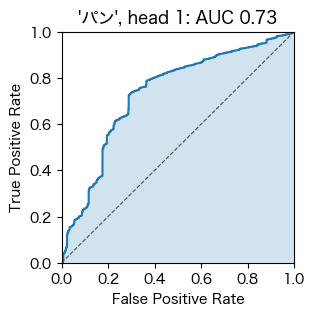

In [17]:
# ROC of this head (bigram counts as weights of the positives)
fpr, tpr, auc = roc(affinity, bigrams, int(df_head["suffix_id"][0]), head)
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(fpr, tpr)
ax.fill_between(fpr, tpr, alpha=0.2)
ax.plot([0, 1], [0, 1], ls="--", c=".3", lw=0.8)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="False Positive Rate", ylabel="True Positive Rate",
       title=f"{TOKENS[int(df_head['suffix_id'][0])]!r}, head {head}: AUC {auc:.2f}")